<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/Zadanie_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zadanie domowe 1 machine learing - PCA

In [ ]:
#importowanie wszytkiego co będzie potem potrzebne
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/Teapot-t/kurs-Uczenie-Maszynowe/refs/heads/main/PCA_three_clusters_data.csv')
data.head()

,x,y,z,class
0,0.647689,-0.138264,3.512299,0
1,-0.234137,-0.234153,10.769447,0
2,-0.469474,0.767435,11.166721,0
3,-0.465730,-0.463418,3.836479,0
4,-1.724918,-1.913280,1.710932,0


In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled.head()

,x,y,z,class
0,-0.833514,-0.588058,0.481100,-1.224745
1,-1.217495,-0.650860,1.630114,-1.224745
2,-1.319970,0.005120,1.693014,-1.224745
3,-1.318340,-0.801014,0.532427,-1.224745
4,-1.866639,-1.750586,0.195892,-1.224745


In [ ]:
print(data['class'].unique())

[0 1 2]


Jak widać, scaler przeskalował również klasy opisujące nasze klastry. Aby scaler nie skalował kolumny 'class', jak i nie wykorzystywał jej do PCA (a można się spodziewać że będzie przechowywała istotną informację o danych co może bardzo wpłynąć na PCA) oddzielamy współrzędne od kolumny z klasami i normalizujemy je osobno. Klasy przechowamy w class labels i zostaną nienaruszone.

In [ ]:
coords = data.drop(columns=['class'])
class_labels = data['class']

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)
coords_scaled = pd.DataFrame(coords_scaled, columns=coords.columns)

print("Skalowane cechy (bez kolumny 'class'):")
display(coords_scaled.head())

Skalowane cechy (bez kolumny 'class'):


,x,y,z
0,-0.833514,-0.588058,0.481100
1,-1.217495,-0.650860,1.630114
2,-1.319970,0.005120,1.693014
3,-1.318340,-0.801014,0.532427
4,-1.866639,-1.750586,0.195892


# Wizualizujemy dane w 3d


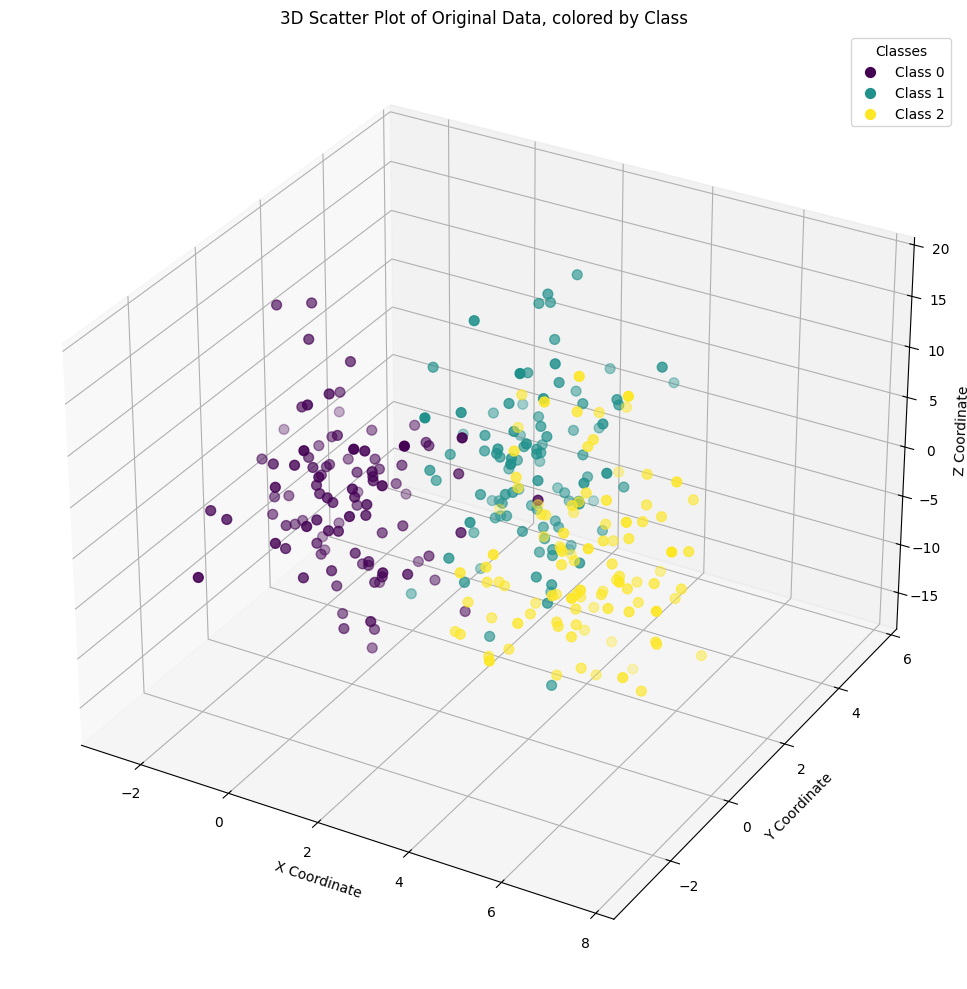

In [ ]:
fig = plt.figure(figsize=(12, 10)) # Increased figure size
ax = fig.add_subplot(111, projection='3d')

# Get unique classes and their colors from the viridis colormap
unique_classes = np.sort(data['class'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

# Plot each class separately to create legend entries
for i, cls in enumerate(unique_classes):
    class_data = data[data['class'] == cls]
    ax.scatter(class_data['x'], class_data['y'], class_data['z'],
               color=colors[i], s=50, label=f'Class {cls}')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('3D Scatter Plot of Original Data, colored by Class')

# Add legend with a title
ax.legend(title='Classes')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Stosujemy PCA.

In [ ]:
pca = PCA(n_components = 2)
coords_pca = pca.fit_transform(coords_scaled)

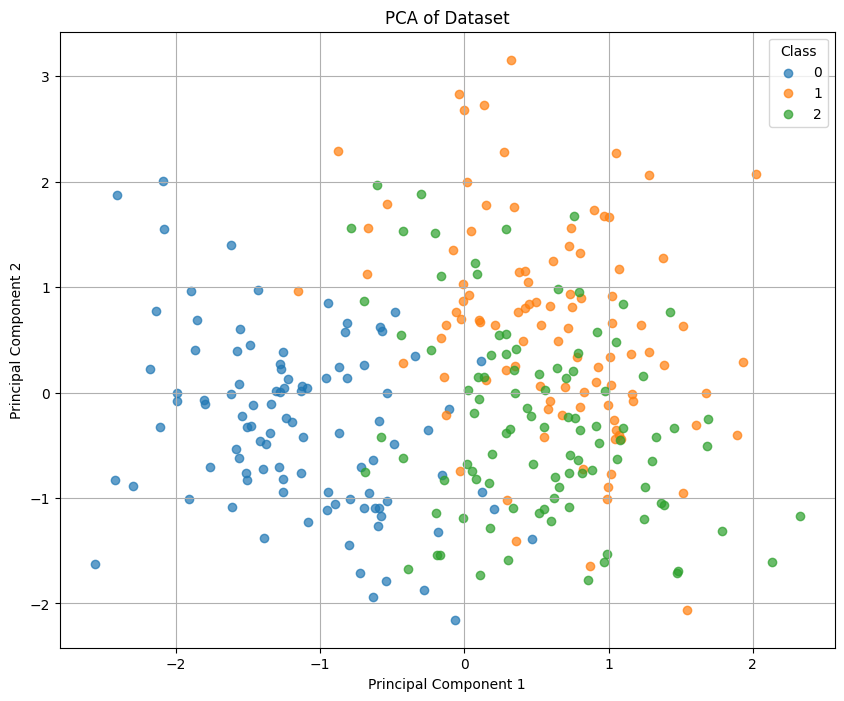

In [ ]:
target_names = data['class'].unique()

plt.figure(figsize=(10, 8))
for i, target_name in enumerate(target_names):
    plt.scatter(coords_pca[class_labels==i, 0], coords_pca[class_labels==i, 1], label=target_name, alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Dataset")
plt.legend(title="Class")
plt.grid(True)
plt.show()

# Robimy wykresy dla pierwotnych danych

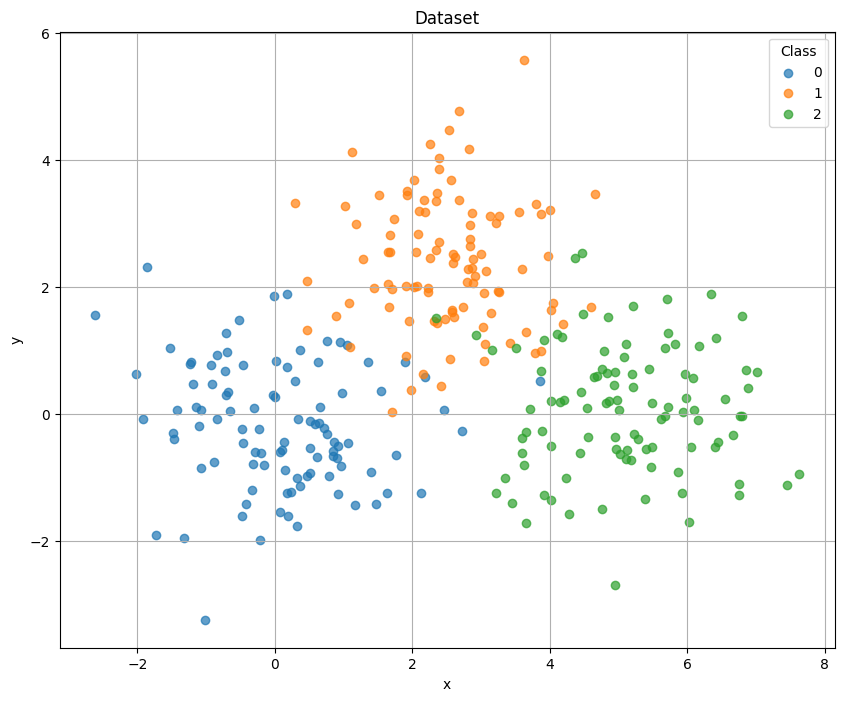

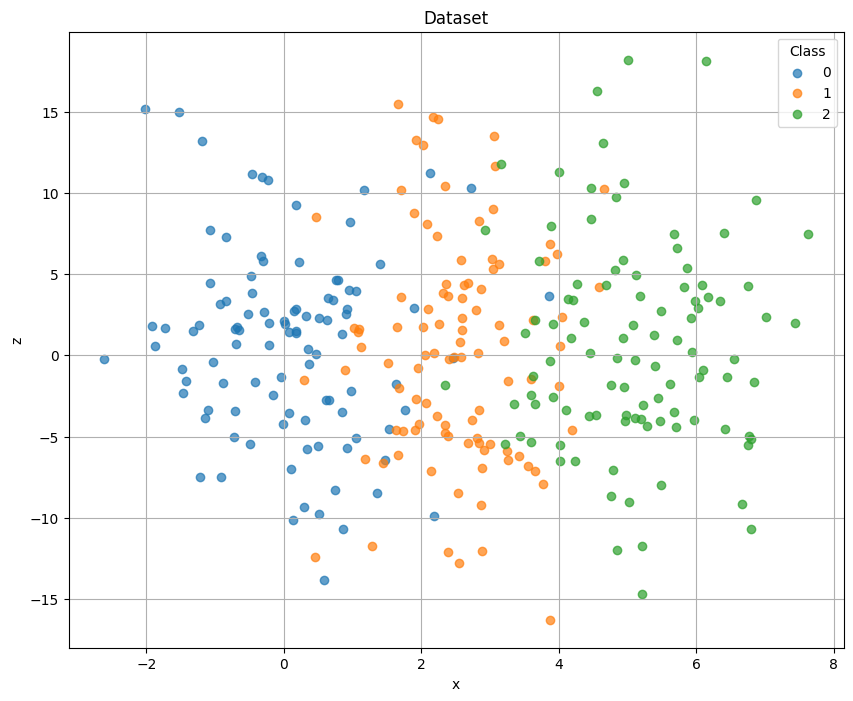

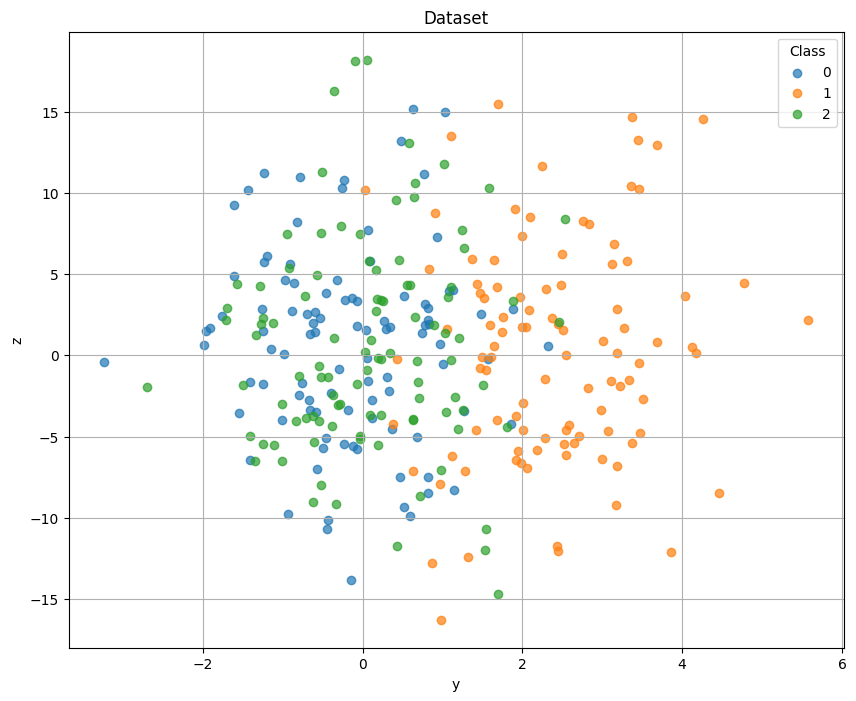

In [ ]:
#wykres x vs y
plt.figure(figsize=(10, 8))
for i, cls in enumerate(data['class'].unique()):
    class_data = data[data['class'] == cls]
    plt.scatter(class_data['x'], class_data['y'], label=cls, alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset")
plt.legend(title="Class")
plt.grid(True)
plt.show()

#wykres x vs z
plt.figure(figsize=(10, 8))
for i, cls in enumerate(data['class'].unique()):
    class_data = data[data['class'] == cls]
    plt.scatter(class_data['x'], class_data['z'], label=cls, alpha=0.7)

plt.xlabel("x")
plt.ylabel("z")
plt.title("Dataset")
plt.legend(title="Class")
plt.grid(True)
plt.show()

#wykres x vs z
plt.figure(figsize=(10, 8))
for i, cls in enumerate(data['class'].unique()):
    class_data = data[data['class'] == cls]
    plt.scatter(class_data['y'], class_data['z'], label=cls, alpha=0.7)

plt.xlabel("y")
plt.ylabel("z")
plt.title("Dataset")
plt.legend(title="Class")
plt.grid(True)
plt.show()

# Odpowiedzi na pytania
1. **Does PCA improve the separation of data points from different clusters compared to the original feature spaces?**

jak widać, PCA zdecydowanie nie poprawiło rozpoznawalności klastrów. Zmienne x i y dają dużo lepszą rozpoznawalność. PCA wybiera kierunki tak aby zmaksymalizować informację dotyczącą wariancji całego zbioru danych. Niestety nie musi to maksymalizować oddzielenia poszczególnych klastrów, PCA nie wykorzystuje żadnej metryki oceniającej skupienie danych.


2. **Why is standardization necessary before applying PCA?**

PCA wybiera kierunki z największą wariancją. Pomnożenie wektora o stałą wartość zwiększa jego wariancję, nawet jeżeli nie daje nam dodatkowej informacji o strukturze danych. Zmienne opisujące zbór danych mające dużo większe wartości (np. mające inny rząd wielkości) mogą zdominować pozostałe i możemy stracić dużo informacji o układzie.